<a href="https://colab.research.google.com/github/anex4real/Assignment-3/blob/main/English_version_of_assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AUDIO ASSIGNMENT

This work aims to process different signals (image, audio, and sinusoidal signals), involving quantization, SNR, and sampling. In addition, the project seeks to understand how the manipulation of bits and sampling affects the quality of the different signals.

## POINT 1

Sampling Frequency: 22050 Hz
Original Audio
N = 2 bits, SNR = 1.55 dB
Audio with 2 bits
N = 4 bits, SNR = 10.94 dB
Audio with 4 bits
N = 6 bits, SNR = 22.86 dB
Audio with 6 bits
N = 8 bits, SNR = 34.89 dB
Audio with 8 bits
N = 10 bits, SNR = 46.94 dB
Audio with 10 bits
N = 12 bits, SNR = 58.96 dB
Audio with 12 bits
N = 14 bits, SNR = 70.78 dB
Audio with 14 bits
N = 16 bits, SNR = 83.06 dB
Audio with 16 bits


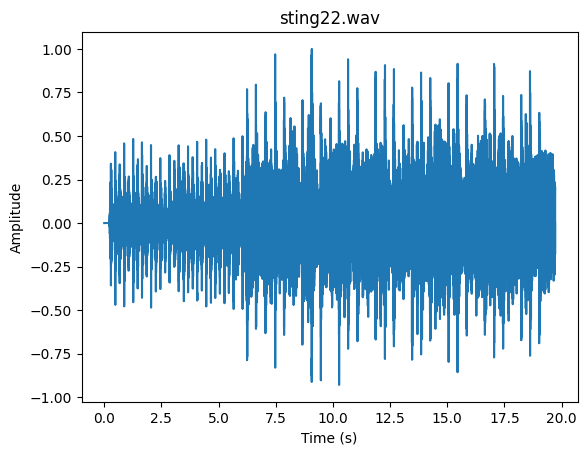

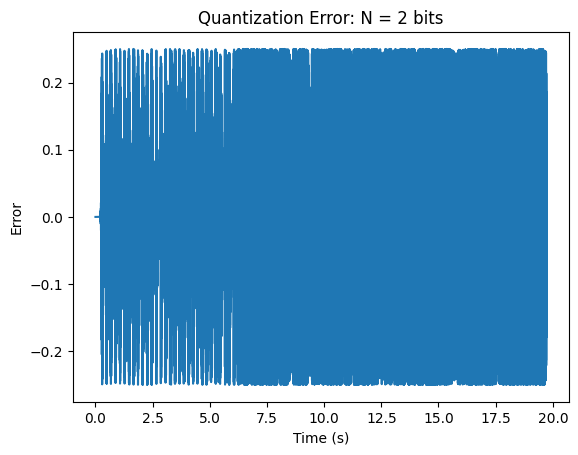

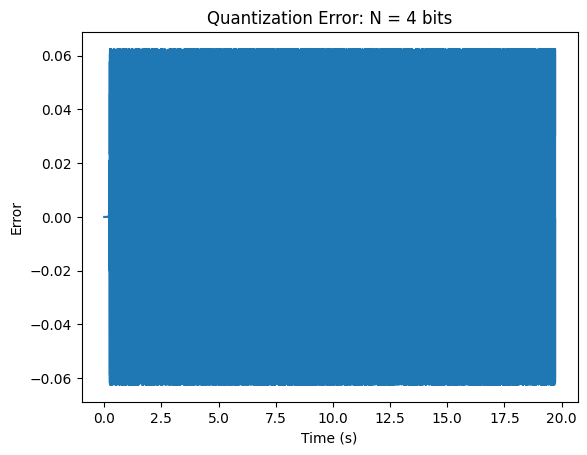

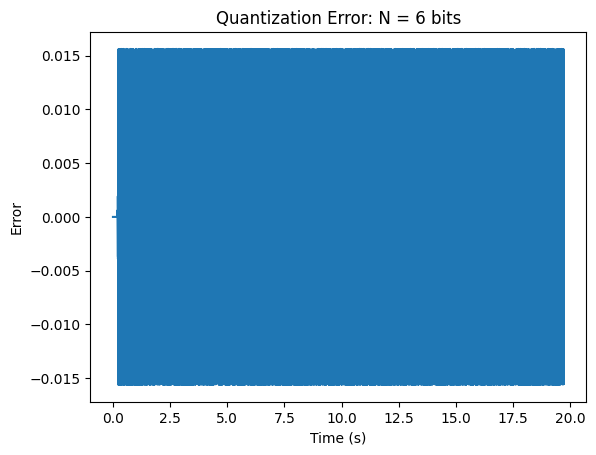

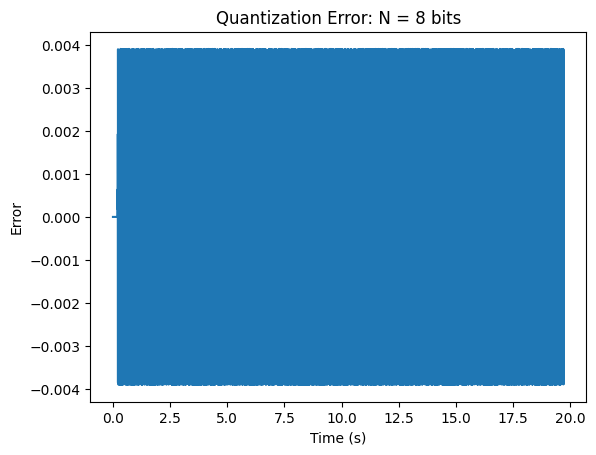

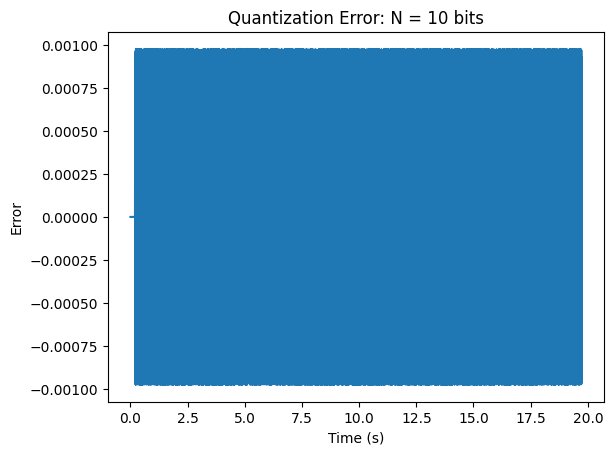

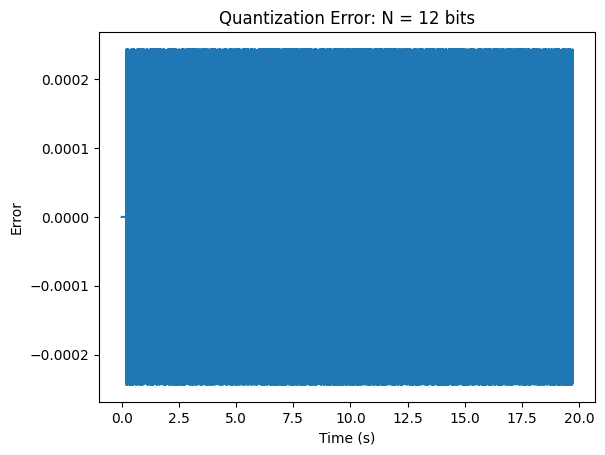

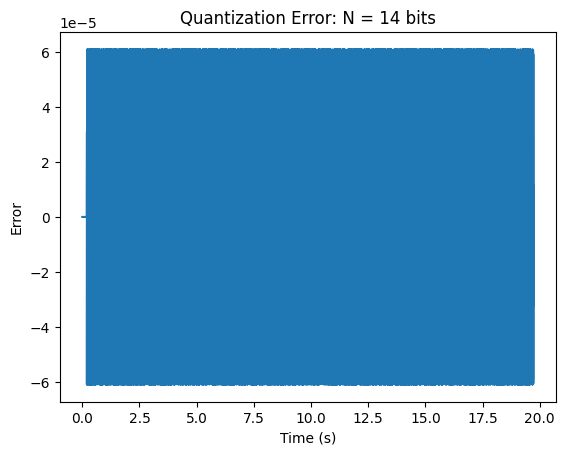

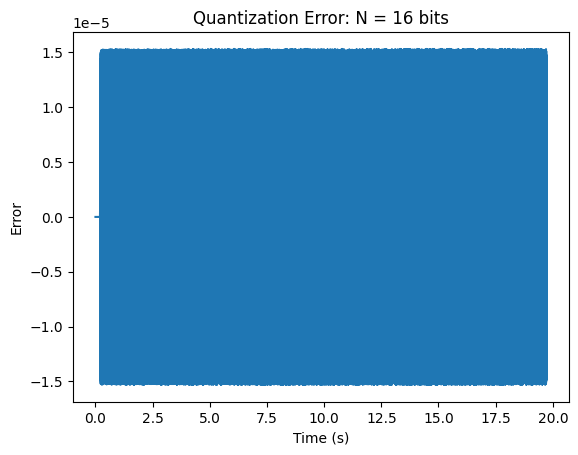

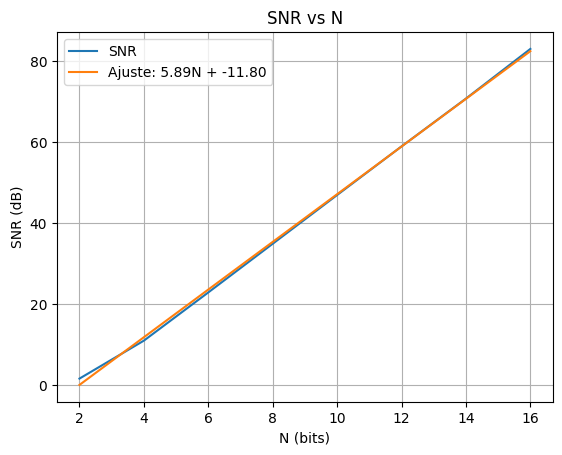


Model: SNR ≈ 5.89 * N + (-11.80)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from PIL import Image
import sounddevice as sd


# AUDIO PART

FS, x = wavfile.read('sting22.wav')
print(f"Sampling Frequency: {FS} Hz")

if x.dtype != np.float32 and x.dtype != np.float64:
    x = x.astype(np.float32)
x = x / np.max(np.abs(x))

def quantizacao(x, N):
    L = 2 ** N
    delta = 2 / L
    xq = np.round((x+1) / delta) * delta - 1
    return xq

def snr (x, erro):
    Px = np.mean(x**2)
    Pe = np.mean(erro**2)

    if Pe == 0:
        return np.inf
    return 10 * np.log10(Px / Pe)

N = [2,4,6,8,10,12,14,16]
snr_v = []

# Reproduz o som original
print("Original Audio")
sd.play(x, FS)
sd.wait()

for i in N:
    q = quantizacao(x, i)
    erro = x - q
    value_snr = snr(x, erro)
    snr_v.append(value_snr)
    print(f"N = {i} bits, SNR = {value_snr:.2f} dB")
    # Tocar áudio quantizado
    print(f"Audio with {i} bits")
    #sd.play(q, FS)
    #sd.wait()

samples = np.arange(len(x))
plt.figure(1)
plt.plot(samples / FS, x)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('sting22.wav')
plt.show()

# ERRO
for i in N:
    q = quantizacao(x, i)
    erro = x - q
    plt.figure()
    plt.plot(samples / FS, erro)
    plt.title(f"Quantization Error: N = {i} bits")
    plt.xlabel('Time (s)')
    plt.ylabel('Error')
    plt.show()

# SNR vs N
plt.figure()
plt.plot(N, snr_v, label='SNR')

# Ajuste linear
coef = np.polyfit(N, snr_v, 1)
reta = np.polyval(coef, N)

plt.plot(N, reta, label=f'Ajuste: {coef[0]:.2f}N + {coef[1]:.2f}')
plt.xlabel('N (bits)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs N')
plt.legend()
plt.grid()
plt.show()
print(f"\nModel: SNR ≈ {coef[0]:.2f} * N + ({coef[1]:.2f})")

## PART 1

This section aims to understand how different numbers of bits change audio quality. This analysis is based on different concepts such as: quantization, quantization error, and SNR.

Steps:
1. Read the audio
2. Normalize
3. Reduce the number of bits in the audio (quantization)
4. Measure the quantization error
5. Calculate SNR
6. Compare with the original audio

##### AUDIO READING

We begin by listening to the audio and extracting two important pieces of information:
- Sampling Frequency (number of samples per second)
- Vector containing the audio signal values

##### NORMALIZATION

We start by checking if the values are decimals, and if not, we convert them. Then, we divide the values by the maximum absolute value of the array to ensure the range is [-1, 1].

##### QUANTIZATION

Quantization means reducing the number of possible levels. If we use only 2 bits, we can only have 4 levels to represent a value; however, if we use 4 bits, we can already have 16 levels.

In this case, if we have N bits, we have 2 raised to the power of N levels, and the more levels we have, the more accurate the sound.

The signal is in the range [-1, 1], meaning the interval is 2, so each level occupies (2 / 2^N). Therefore:
- If the number of bits is small, each level occupies a large space, leading to large jumps and poorer quality
- If the number of bits is large, each level occupies a small space, making it more precise and improving quality

##### QUANTIZATION ERROR

This corresponds to the difference between the original signal and the quantized signal, measuring what is lost during quantization.

error = x_original - x_quantized

#### SNR (SIGNAL-TO-NOISE RATIO)

It measures how strong the signal is compared to the noise, and the higher the SNR, the better the sound quality. Therefore, if the error is small, the SNR is high; otherwise, the SNR is low.

SNR = 10 * log10 (mean(x^2) / mean(error^2))

#### TEMPORAL REPRESENTATION OF THE SIGNAL (ORIGINAL AUDIO)

Steps:
1. Create an array with the index of each sample
2. Convert each index into real time by dividing by FS
3. Plot a graph where the x-axis corresponds to time and the y-axis corresponds to the signal amplitude (already normalized between [-1, 1])

This graph represents the waveform of the audio and explains how the sound varies over time, highlighting regions with more energy and regions where energy is absent.

#### GRAPH ANALYSIS (QUANTIZATION)

These graphs show how the error varies over time. For:

- 2 Bits: Having 2 bits means only 4 levels, and the quantization step is 2/4 = 0.5. This means the signal must fall into a few possible values separated by this step, which distorts the audio. As observed, the error tends to stay between -0.25 and 0.25 ([-error interval/2, error interval/2]) because rounding is always to the nearest level. Additionally, the plot shows high density because we are representing a large number of samples within only 20 seconds. At the beginning, there are regions with weaker sound, where the amplitude is smaller, and the signal may get stuck at certain levels, becoming more concentrated there. Later, the sound becomes more uniform.

- 4 Bits: In this case, the error ranges from -0.062 to 0.062 and the quantization interval is 0.125. The error is smaller compared to the previous case, and the graph appears more filled, although irregularities and imperfections still exist, but are less noticeable.

- 6 Bits: Here, the error varies between [-0.015625, 0.015625], with 64 levels. The error continues to decrease significantly.

- 8 Bits: In this case, each sample has 256 levels, and the difference between levels is 0.0078, making the graph appear almost completely filled, as the error is very small and barely noticeable.

- 10 Bits: With this number of bits, we have 1024 quantization levels, and the error varies between [-0.001, 0.001], which is extremely small. The graph appears as a thin band close to zero, with imperfections becoming almost imperceptible.

- 12 Bits: Corresponds to 4096 levels, and the graph resembles a uniform block. The error behaves like very low noise.

- 14 Bits: 16384 levels and an error interval of approximately 0.00012, making variations almost indistinguishable, even more so than in previous cases.

- 16 Bits: With 65536 quantization levels, the error is practically zero, resulting in a graph that appears as a horizontal line along the zero axis.

We conclude that as N increases, the error progressively decreases. The imperfections observed in the graphs disappear as the number of bits increases because the error becomes smaller, making transitions between levels less abrupt and less noticeable.

#### SNR VS NUMBER OF BITS GRAPH

In this graph, we plot the variation of SNR as a function of the number of bits.

In the exercise, we model the relationship between SNR and the number of bits using a linear model (first-order) with polyfit, that is: y = aN + b. Then, we use polyval to plot the corresponding line.

Note: np.polyfit(N, snr_v, 1) returns coefficients [a, b], where a is the slope and b is the intercept with the y-axis.

We can conclude that SNR increases linearly with the number of bits used for quantization.

The obtained model indicates that SNR = 5.89⋅N − 11.80, while the theoretical value is SNR = 6.02⋅N + 1.76 (valid for sinusoidal signals and ideal quantization). This means the slope obtained in this experiment is very close to the theoretical one, and the difference may be due to the audio not being purely sinusoidal (it may have amplitude variations over time, making it a complex signal rather than a simple wave).

The larger the N, the higher the SNR, and consequently, the cleaner and more precise the sound. On the other hand, when the number of bits is low, the SNR is low, resulting in noisier audio.

In summary, in this specific exercise, each additional bit increases the SNR by approximately 6 dB, which is very close to the theoretical value. Additionally, the SNR increases linearly with the number of bits.


## POINT 2

When we perform quantization, we force a signal to have a finite set of levels. The smaller the number of levels, the greater the distance between them, and the higher the probability of information loss, resulting in more noise (fewer levels → greater distance between levels → higher quantization error). This noise is perceived as distortion and robotic-like sound.

In this exercise, audio quality varies according to the number of bits:
- With 2 bits, almost only noise is heard, and very few words are perceptible, including the rhythm of the music, due to very strong quantization and high noise.
- With 4 bits, there is some improvement; however, there is still a lot of background noise.
- With 6 bits, the noise becomes lighter and less noticeable, and there is a clear improvement in the perception of words and rhythm.
- From 8 bits up to 16 bits, the audio is clearly audible with no noticeable noise, highlighting the quality of the audio signal. The levels are much closer together, the quantization error is much smaller than in previous cases, and the SNR is significantly higher.

In summary, the minimum number of bits required to achieve acceptable audio quality in this case is 8 bits. As the number of bits used in quantization increases, the number of levels also increases, leading to better audio quality; however, this improvement becomes imperceptible to the human ear beyond a certain point.

## POINT 3

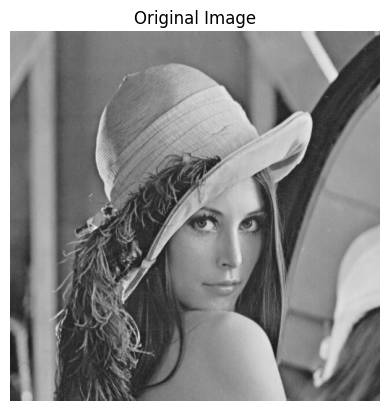

N=2: SNR = 13.96 dB
N=3: SNR = 21.82 dB
N=4: SNR = 28.60 dB
N=5: SNR = 34.97 dB
N=6: SNR = 41.16 dB
N=7: SNR = 47.88 dB
N=8: SNR = inf dB


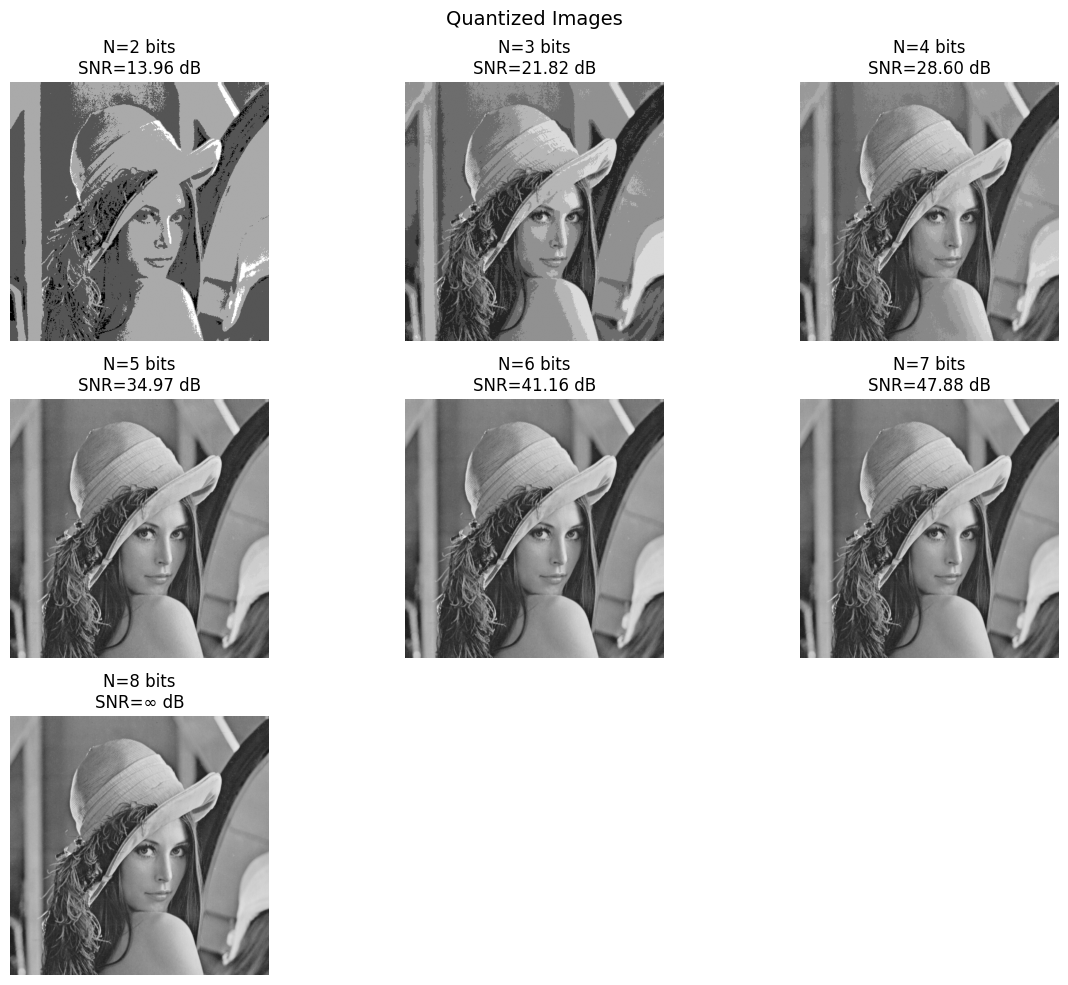

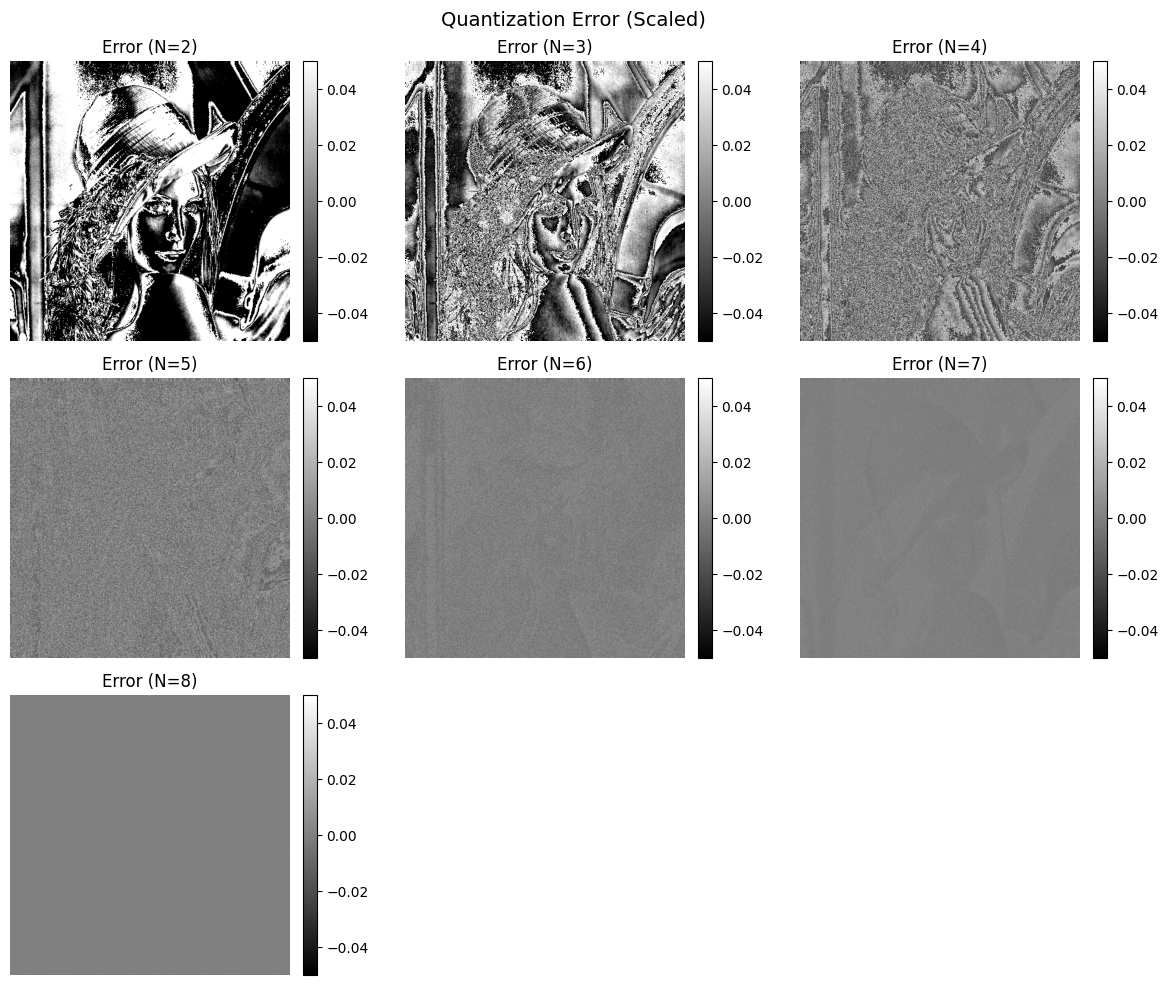


Linear model (polyfit): SNR = 6.69 * N + (1.31) dB
Slope ≈ 6.69 dB/bit (theoretical ≈ 6.02 dB/bit)


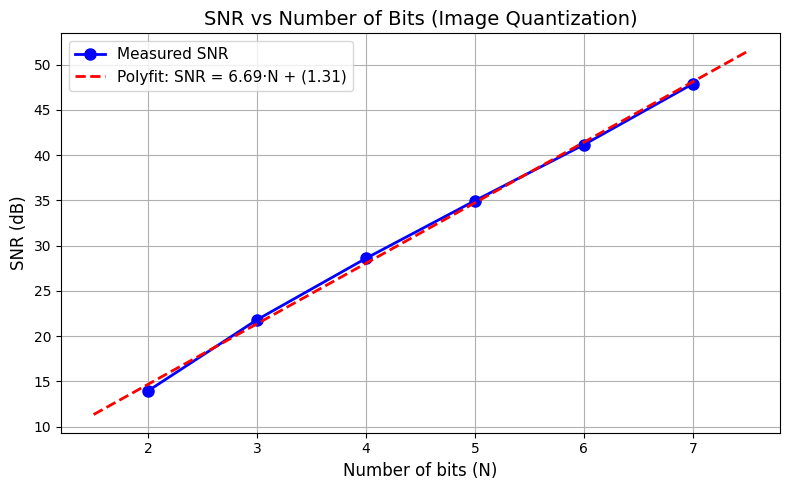

In [ ]:
#  (Q3 + Q4 )

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


img = Image.open('lena512.bmp').convert('L')
A = np.array(img, dtype=np.float32)


plt.figure()
plt.imshow(A, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')
plt.show()


A = A / 255.0


def quantize_image(image, N):
    L = 2**N
    return np.round(image * (L - 1)) / (L - 1)

def compute_snr(original, reconstructed):
    signal_power = np.mean(original**2)
    noise = original - reconstructed
    noise_power = np.mean(noise**2)
    if noise_power == 0:
        return np.inf
    return 10 * np.log10(signal_power / noise_power)


N_values = [2, 3, 4, 5, 6, 7, 8]
snr_values = []
quantized_images = {}

for N in N_values:
    Aq = quantize_image(A, N)
    snr = compute_snr(A, Aq)
    snr_values.append(snr)
    quantized_images[N] = Aq
    print(f"N={N}: SNR = {snr:.2f} dB")


plt.figure(figsize=(12, 10))
for i, N in enumerate(N_values):
    Aq_display = (quantized_images[N] * 255).astype(np.uint8)
    plt.subplot(3, 3, i+1)
    plt.imshow(Aq_display, cmap='gray', vmin=0, vmax=255)
    snr_str = f'{snr_values[i]:.2f}' if np.isfinite(snr_values[i]) else '∞'
    plt.title(f'N={N} bits\nSNR={snr_str} dB')
    plt.axis('off')

plt.suptitle('Quantized Images', fontsize=14)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 10))
for i, N in enumerate(N_values):
    error = A - quantized_images[N]
    plt.subplot(3, 3, i+1)
    im = plt.imshow(error, cmap='gray', vmin=-0.05, vmax=0.05)
    plt.title(f'Error (N={N})')
    plt.axis('off')
    plt.colorbar(im, fraction=0.046, pad=0.04)

plt.suptitle('Quantization Error (Scaled)', fontsize=14)
plt.tight_layout()
plt.show()


N_finite = [n for n, s in zip(N_values, snr_values) if np.isfinite(s)]
snr_finite = [s for s in snr_values if np.isfinite(s)]


a, b = np.polyfit(N_finite, snr_finite, 1)

print(f"\nLinear model (polyfit): SNR = {a:.2f} * N + ({b:.2f}) dB")
print(f"Slope ≈ {a:.2f} dB/bit (theoretical ≈ 6.02 dB/bit)")

fig, ax = plt.subplots(figsize=(8, 5))


ax.plot(N_finite, snr_finite, 'bo-', markersize=8, linewidth=2, label='Measured SNR')


if len(N_finite) < len(N_values):
    ax.annotate('N=8: SNR = ∞ (perfect reconstruction)',
                xy=(8, max(snr_finite)*0.95),
                fontsize=10, color='green',
                ha='right',
                arrowprops=dict(arrowstyle='->', color='green'))


N_fit = np.linspace(N_finite[0] - 0.5, N_finite[-1] + 0.5, 200)
snr_fit = a * N_fit + b
ax.plot(N_fit, snr_fit, 'r--', linewidth=2,
        label=f'Polyfit: SNR = {a:.2f}·N + ({b:.2f})')


ax.set_xlabel('Number of bits (N)', fontsize=12)
ax.set_ylabel('SNR (dB)', fontsize=12)
ax.set_title('SNR vs Number of Bits (Image Quantization)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True)

fig.tight_layout()
plt.show()

# POINT 4

The image was converted to grayscale and normalized to the range [0, 1]. It was then quantized for bit depths from N = 2 to N = 8 using uniform quantization with rounding. For each case, the quantization error was computed, and the SNR was obtained as the ratio between the signal power and the error power in dB.

The results show that the SNR increases approximately linearly with the number of bits. A linear model obtained using polyfit (excluding N = 8, which yields infinite SNR) confirms this trend, with a slope close to the expected value of about 6 dB per bit. This indicates that each additional bit significantly reduces the quantization error.

From the visual analysis, the error is strongly structured at low bit depths and becomes weaker and more noise-like as N increases. A fixed display scale was used for all error images to allow a fair comparison of error magnitude across different values of N, avoiding misleading contrast differences due to automatic rescaling

Looking at the quantized images, the degradation is very clear at low bit depths. At N = 2, with only 4 grey levels, the image is reduced to something closer to a rough sketch, with harsh transitions between flat regions far from a natural photograph. At N = 3 (8 levels), there is some improvement, but the banding in smooth areas such as the background and skin is still very noticeable.

At N = 4, the image appears reasonable at first glance, but closer inspection reveals contouring in gradual intensity transitions, particularly around the hat and shoulder. These discontinuities between quantization levels are still clearly visible.

At N = 5 (32 levels), the contouring is no longer obvious under normal viewing conditions. The image looks clean overall, although faint artifacts can still be detected in the smoothest regions if examined carefully. For most practical purposes, this is where the quality becomes acceptable.

By N = 6, no visible artifacts could be identified, even when focusing on smooth gradients. The image appears indistinguishable from the original. Increasing the bit depth further (N = 7 and N = 8) does not produce any noticeable visual improvement.

Overall, the minimum number of bits depends on the level of strictness. A value of N = 5 bits is sufficient for visually acceptable, artifact-free viewing in typical conditions, while N = 6 bits provides a more conservative threshold where no degradation is perceptible even upon close inspection. This aligns with the observation that, at this point, the quantization error becomes small and largely noise-like, rather than structured and visually disturbing.

# PART 5(i)

*To simulate sampling and reconstruction in a digital system:*

**1.   Generate:** Create a 100 Hz sine wave sampled at 8000 Hz.

**2.   Decimate ($F$):** Reduce the sampling rate by keeping only every $F^{th}$ sample.

**3.   Upsample:** Insert $F-1$ zeros between samples to return to the original data length.

**4.   Reconstruct:** Use a Zero-Order Hold (repetition filter) to fill the zeros with the previous sample value.



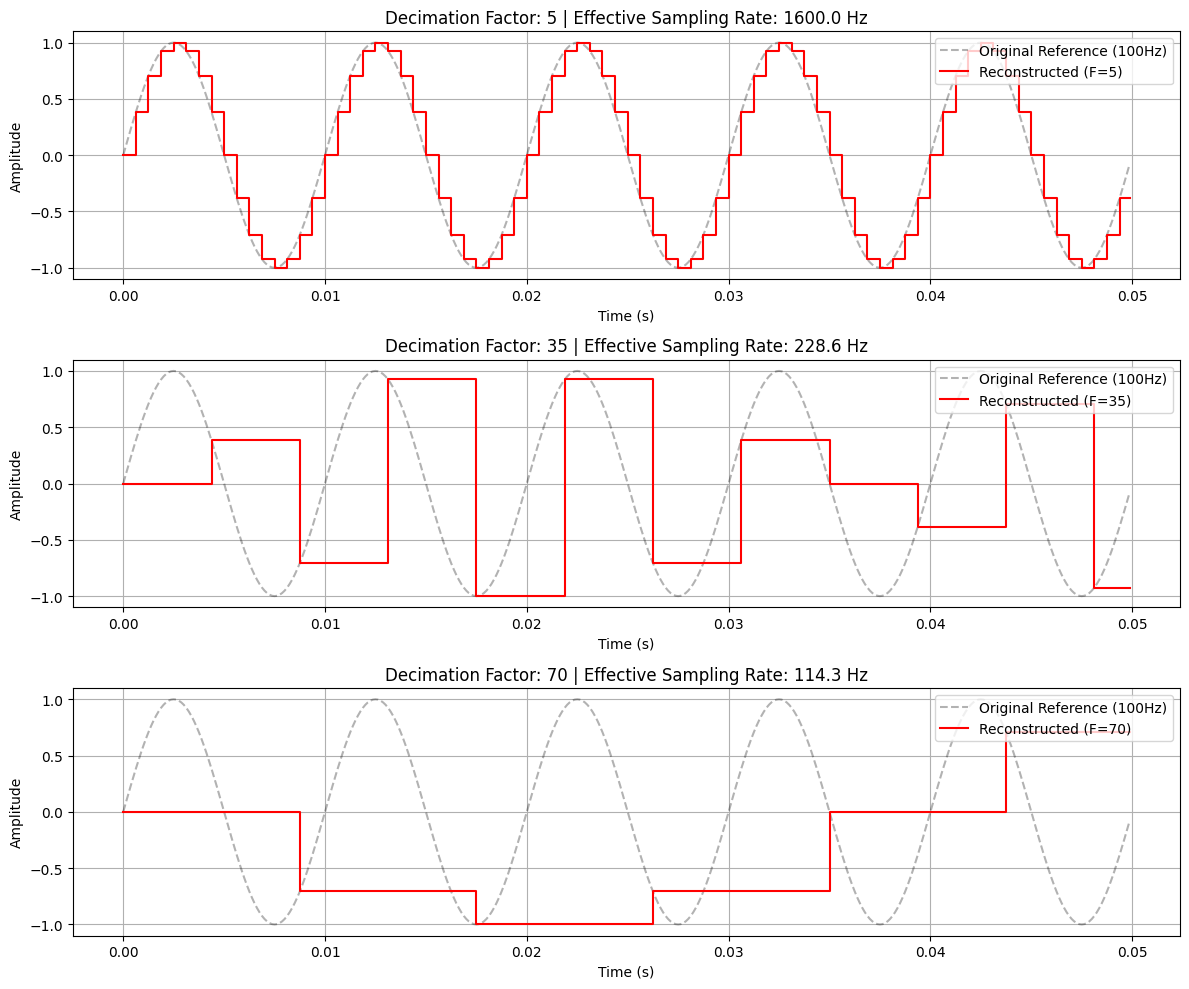

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from PIL import Image

def load_assets():
    try:
        sr, audio = wavfile.read('sting22.wav')
        img = np.array(Image.open('lena512.bmp'))
        return sr, audio, img
    except FileNotFoundError:
        return None, None, None

def run_sampling_experiment():
    # Signal Configuration
    fs = 8000
    f_signal = 100
    duration = 0.05
    t = np.arange(0, duration, 1/fs)
    x = np.sin(2 * np.pi * f_signal * t)

    # Decimation factors for 5.ii analysis
    F_values = [5, 35, 70]

    plt.figure(figsize=(12, 10))

    for i, F in enumerate(F_values):
        # 1. Decimation (Downsampling)
        x_dec = x[::F]

        # 2. Upsampling (Expansion)
        x_up = np.zeros(len(x))
        x_up[::F] = x_dec

        # 3. Reconstruction (Zero-Order Hold / Sample Repetition)
        # Implemented via a FIR filter with coefficients set to 1
        h = np.ones(F)
        x_recon = signal.lfilter(h, 1, x_up)

        # 4. Data Visualization
        fs_eff = fs / F
        plt.subplot(3, 1, i+1)
        plt.plot(t, x, 'k--', alpha=0.3, label="Original Reference (100Hz)")
        plt.step(t, x_recon, where='post', color='red', label=f"Reconstructed (F={F})")

        plt.title(f"Decimation Factor: {F} | Effective Sampling Rate: {fs_eff:.1f} Hz")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.grid(True)
        plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Load files for environment verification
    samplerate, audio_data, image_data = load_assets()

    # Execute Exercise 5
    run_sampling_experiment()

# PART 5(ii)


*   **(F) = 5:** At an Effective Sampling Frequency ($f_s$) of 1600.0 Hz, we observe a Clean and Accurate Sinusoidal Representation. This is considered a Safe Sampling Region because the effective rate is significantly higher than the 200 Hz Nyquist limit ($f_s > 2f$), allowing the 100 Hz frequency to be perfectly preserved without any distortion.

*   **(F) = 35:** At an Effective Sampling Frequency ($f_s$) of ~228.6 Hz, the waveform becomes a Highly Distorted and Jagged Structure. This indicates we are Approaching the Critical Limit; as the rate nears 200 Hz, the sample density drops to roughly 2.2 samples per cycle, making the wave identifiable but of very poor quality.



*   **(F) = 70:** At an Effective Sampling Frequency ($f_s$) of ~114.3 Hz, the result is an Incorrect Low-Frequency Alias Generation. This is a direct Nyquist Violation because the sampling rate is below 200 Hz ($f_s < 2f$), causing the signal to alias and creating a "phantom" low-frequency wave that does not exist in the original signal.


# POINT 6

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from PIL import Image
import sounddevice as sd
from scipy.signal import lfilter

FS, x = wavfile.read('sting22.wav')

if x.dtype != np.float32 and x.dtype != np.float64:
    x = x.astype(np.float32)
x = x / np.max(np.abs(x))

img = Image.open('lena512.bmp').convert('L')
x_image = np.array(img, dtype=np.float32) / 255.0
x_image_v2 = np.array(img, dtype=np.float32)

plt.figure()
plt.imshow(x_image_v2, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image')
plt.axis('off')
plt.show()

factors = [2,4]

def downsampling_image(signal, factor):
    return signal[::factor, ::factor]

def upsampling_image(signal, factor):
    modificated = np.repeat(signal, factor, axis=0)
    final = np.repeat(modificated, factor, axis=1)
    return final

def downsampling_audio(signal, factor):
    return signal[::factor]

def upsampling_audio(signal, factor):
    return np.repeat(signal, factor)

# IMAGE
plt.figure(figsize=(10, 5))
for i, factor in enumerate(factors):
    down_signal = downsampling_image(x_image, factor)
    final = upsampling_image(down_signal, factor)
    plt.subplot(1, len(factors), i+1)
    plt.imshow(final, cmap='gray', vmin=0, vmax=1)
    plt.title(f'Image Reconstructed F={factor}')
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Original Audio")
sd.play(x, FS)
sd.wait()

# AUDIO
plt.figure(figsize=(12, 6))
for i, factor in enumerate(factors):
    down = downsampling_audio(x, factor)
    reconstructed = upsampling_audio(down, factor)
    print(f"\n Audio for F={factor}...")
    sd.play(reconstructed, FS)
    sd.wait()

This exercise aims to change the sampling rate of signals (audio and image) to observe the effects on signal quality.

To carry out this task, we need to understand some important concepts, including:

Downsampling: This consists of reducing the signal's samples by eliminating some of them. This allows reducing the size of an image or the audio rate. However, when signals contain high frequencies, there is a risk of aliasing and loss of essential information. In other words, audio may sometimes become robotic and of low quality, and images may become pixelated. When we perform downsampling with a factor F = 2, we create a signal with half the original samples.
Upsampling: This consists of increasing the number of samples in a signal. This technique aims to reconstruct signals that have a reduced size, using a factor F.

The method we will use in this step to assign values to the '0's created after upsampling is sample repetition; that is, each inserted 0 is replaced by the previous sample's value. Therefore, in audio, the value becomes continuous and does not produce fine or deep variations, and in images, the pixel becomes blurred.

#### IMAGE RECONSTRUCTION (ANALYSIS OF RECONSTRUCTIONS)

Regarding image reconstruction, we start by reading and normalizing the image and then defining the downsampling factors. Image reconstruction is done by repeating neighboring samples, creating spaces for the inserted '0's and then copying the adjacent values into these spaces.

After performing downsampling and upsampling with a factor F, we obtained two images, one for each F value (F = 2 and F = 4), and in both images, we can see horizontal and vertical lines caused by information loss.

When we downsample with F = 2, we lose 1 out of every 2 pixels, and with F = 4, we lose 1 out of every 4 pixels. In other words, high-frequency pixels are removed, which later causes image distortion. When we upsample, we replicate each pixel’s value, so each pixel becomes a block of that value. Essentially, we are not recovering details; we are just stretching the smaller image back to the original size by repeating the existing sample values.

In this case, the image with F = 4 is much more degraded than the image with F = 2, because the higher the F, the greater the amount of lost information, especially high-frequency details, causing aliasing. Additionally, reconstruction requires creating larger identical blocks, which further emphasizes pixelation. In short, the quality loss in the F = 2 image is moderate and barely noticeable, whereas with F = 4, the quality loss is clearly evident.

#### AUDIO RECONSTRUCTION (ANALYSIS OF RECONSTRUCTIONS)

The audio with F = 2 shows a slight loss of quality; in some moments, the sound becomes slightly robotic. However, in the audio with F = 4, the loss of quality is much more noticeable, as there is stronger aliasing and a loss of high frequencies, which distorts the sound.

Therefore, we can conclude that the higher the value of F, the greater the loss of audio quality, and the further the signal is from the original sound.

#### CONCLUSIONS

For audio, when performing downsampling, we lose important sound information, which reduces audio quality. Later, with upsampling, we try to recover the lost values; however, these are not identical to the originals, so the loss of information and overall sound quality is noticeable.

Regarding images, downsampling causes the loss of important pixels, resulting in a pixelated image. Even after increasing the number of samples, the image never regains the quality of the original, with pixels appearing deformed and, especially, stretched.

We could have used a more effective upsampling method, such as linear interpolation (which uses a weighted average of neighboring samples), resulting in less signal quality loss during the transformation.